In [4]:
import math

# 1. Defining the game board
# We use a 1D list where indices 0-8 represent the 3x3 grid
def create_board():
    return [" " for _ in range(9)]

def print_board(board):
    for i in range(0, 9, 3):
        print(f"{board[i]} | {board[i+1]} | {board[i+2]}")
        if i < 6:
            print("-" * 9)

# 2. Checking if a player has won
# Returns True if the player has three in a row
def check_winner(board, player):
    win_conditions = [
        (0, 1, 2), (3, 4, 5), (6, 7, 8), # Rows
        (0, 3, 6), (1, 4, 7), (2, 5, 8), # Columns
        (0, 4, 8), (2, 4, 6)             # Diagonals
    ]
    return any(board[a] == board[b] == board[c] == player for a, b, c in win_conditions)

# 3. Checking if the game is a tie
# Returns True if no empty spaces remain and no one has won
def is_tie(board):
    return " " not in board

# Simple AI Agent Logic (Minimax)
def get_ai_move(board):
    best_score = -math.inf
    move = None
    for i in range(9):
        if board[i] == " ":
            board[i] = "X" # AI is X
            score = minimax(board, 0, False)
            board[i] = " "
            if score > best_score:
                best_score = score
                move = i
    return move

def minimax(board, depth, is_maximizing):
    if check_winner(board, "X"): return 1
    if check_winner(board, "O"): return -1
    if is_tie(board): return 0

    if is_maximizing:
        best_score = -math.inf
        for i in range(9):
            if board[i] == " ":
                board[i] = "X"
                score = minimax(board, depth + 1, False)
                board[i] = " "
                best_score = max(score, best_score)
        return best_score
    else:
        best_score = math.inf
        for i in range(9):
            if board[i] == " ":
                board[i] = "O"
                score = minimax(board, depth + 1, True)
                board[i] = " "
                best_score = min(score, best_score)
        return best_score

# 4. Main game loop
# Handles turns, inputs, and state updates
def main_game_loop():
    board = create_board()
    current_player = "O" # Human starts as O
    
    print("Welcome to Tic-Tac-Toe! Enter 0-8 to move.")
    print_board(board)

    while True:
        if current_player == "O":
            try:
                move = int(input("Your move (0-8): "))
                if board[move] != " ":
                    print("Spot taken!")
                    continue
            except (ValueError, IndexError):
                print("Invalid input.")
                continue
        else:
            print("\nAI is thinking...")
            move = get_ai_move(board)

        board[move] = current_player
        print_board(board)

        if check_winner(board, current_player):
            print(f"\nPlayer {current_player} wins!")
            break
        if is_tie(board):
            print("\nIt's a tie!")
            break

        current_player = "X" if current_player == "O" else "O"

# 5. Call the main game loop
if __name__ == "__main__":
    main_game_loop()

Welcome to Tic-Tac-Toe! Enter 0-8 to move.
  |   |  
---------
  |   |  
---------
  |   |  
Your move (0-8): 5
  |   |  
---------
  |   | O
---------
  |   |  

AI is thinking...
  |   | X
---------
  |   | O
---------
  |   |  
Your move (0-8): 5
Spot taken!
Your move (0-8): 5
Spot taken!
Your move (0-8): 4
  |   | X
---------
  | O | O
---------
  |   |  

AI is thinking...
  |   | X
---------
X | O | O
---------
  |   |  
Your move (0-8): 7
  |   | X
---------
X | O | O
---------
  | O |  

AI is thinking...
  | X | X
---------
X | O | O
---------
  | O |  
Your move (0-8): 0
O | X | X
---------
X | O | O
---------
  | O |  

AI is thinking...
O | X | X
---------
X | O | O
---------
  | O | X
Your move (0-8): 6
O | X | X
---------
X | O | O
---------
O | O | X

It's a tie!


In [1]:
pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


Data created locally! Generating your charts now...


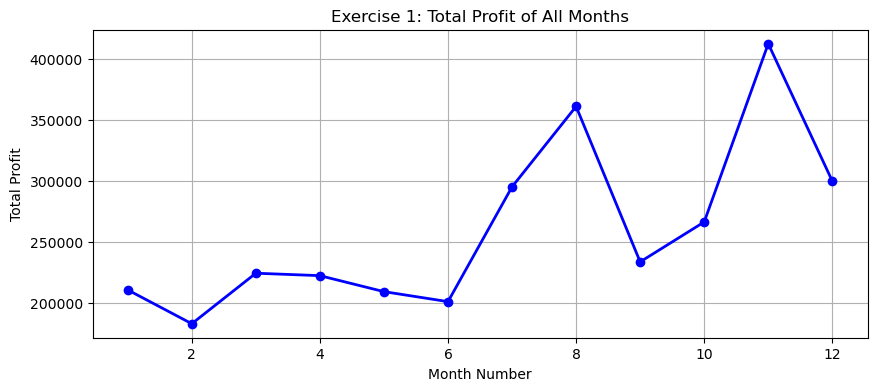

In [2]:
##Testing exercise two

import matplotlib.pyplot as plt 
import pandas as pd 
# The exact numbers from the monthly_sales.csv assignment file typed manually 

raw_data = { "month_number": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 
            "bathingsoap": [ 9200, 6100, 9550, 8870, 7760, 7490, 8980, 9960, 8100, 10300, 13300, 14400, ], 
            "total_profit": [ 211000, 183300, 224700, 222700, 209600, 201400, 295500, 361400, 234000, 266700, 412800, 300200, ],
           } 
# Turn the numbers directly into a usable Dataframe without using a link 

df = pd.DataFrame(raw_data) 
print("Data created locally! Generating your charts now...") 

# --- Exercise 1: Total Profit Line Plot --- 

plt.figure(figsize=(10, 4)) 
plt.plot( df["month_number"], df["total_profit"], marker="o", color="blue", linewidth=2, ) 
plt.title("Exercise 1: Total Profit of All Months") 
plt.xlabel("Month Number") 
plt.ylabel("Total Profit") 
plt.grid(True) 
plt.show() 


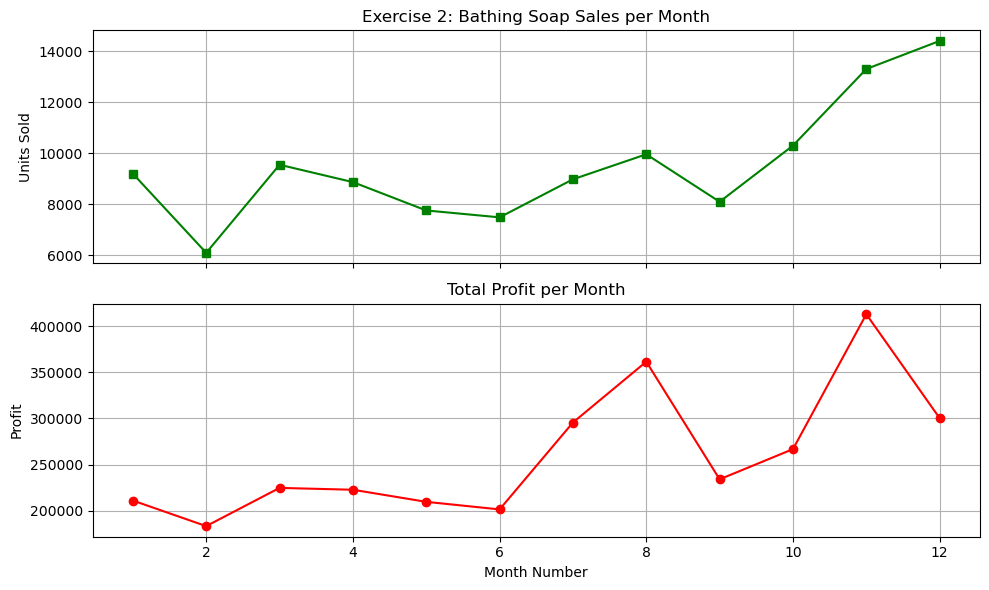

In [3]:
# --- Exercise 2: Bathing Soap Subplot --- 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True) 

# Top Chart: Bathing Soap Units Sold 

ax1.plot(df["month_number"], df["bathingsoap"], marker="s", color="green") 
ax1.set_title("Exercise 2: Bathing Soap Sales per Month") 
ax1.set_ylabel("Units Sold") 
ax1.grid(True) 

# Bottom Chart: Total Profit Comparison 

ax2.plot(df["month_number"], df["total_profit"], marker="o", color="red") 
ax2.set_title("Total Profit per Month") 
ax2.set_xlabel("Month Number") 
ax2.set_ylabel("Profit") 
ax2.grid(True) 
plt.tight_layout() 
plt.show()